# 5. Multi-Head Attention

**Цель:** Расширить Scaled Dot-Product Attention до многоголового внимания — ключевого компонента трансформеров.

---

In [1]:
# Импорт библиотек для реализации Multi-Head Attention
import sys, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Автовыбор устройства: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


## 5.1 Идея Multi-Head Attention

**Проблема одного внимания:** Одна матрица внимания — один паттерн взаимодействия между токенами.

**Идея:** Использовать h разных "голов" внимания, каждая со своими проекциями Q, K, V:
- Разные головы учат разные типы отношений (синтаксические, семантические, позиционные)
- Каждая голова работает в подпространстве меньшей размерности: d_k = d_model / h
- Результаты конкатенируются и проецируются обратно в d_model

**Формула:**
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W_O$$
$$\text{head}_i = \text{Attention}(QW_Q^i, KW_K^i, VW_V^i)$$

In [2]:
# Multi-Head Attention: ключевой компонент архитектуры трансформера
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention с нуля."""
    
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # размерность одной головы
        
        # Проекционные слои Q, K, V: каждый размером d_model -> d_model
        # Это позволяет всем головам共用 (share) одни и те же линейные слои
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        
        # Финальная проекция после конкатенации голов
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def _split_heads(self, x):
        """Разделяем d_model на n_heads голов размерности d_k."""
        # (batch, seq_len, d_model) -> (batch, seq_len, n_heads, d_k) -> (batch, n_heads, seq_len, d_k)
        batch, seq_len, _ = x.shape
        x = x.view(batch, seq_len, self.n_heads, self.d_k)
        return x.transpose(1, 2)  # меняем местами seq_len и n_heads
    
    def _combine_heads(self, x):
        """Обратная операция: собираем головы обратно в d_model."""
        # (batch, n_heads, seq_len, d_k) -> (batch, seq_len, n_heads, d_k) -> (batch, seq_len, d_model)
        batch, _, seq_len, _ = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch, seq_len, self.d_model)
    
    def forward(self, Q, K, V, mask=None):
        """
        Прямой проход Multi-Head Attention.
        
        Args:
            Q, K, V: (batch, seq_len, d_model)
            mask: (batch, seq_len) — padding mask
        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, n_heads, seq_len, seq_len)
        """
        batch = Q.size(0)
        
        # 1. Линейные проекции Q, K, V
        Q = self.W_Q(Q)  # (batch, seq_len, d_model)
        K = self.W_K(K)
        V = self.W_V(V)
        
        # 2. Разделение на n_heads голов
        Q = self._split_heads(Q)  # (batch, n_heads, seq_len, d_k)
        K = self._split_heads(K)
        V = self._split_heads(V)
        
        # 3. Scaled Dot-Product Attention для КАЖДОЙ головы
        # Все головы считаются параллельно благодаря матричным операциям
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Маскировка (padding mask)
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        output = torch.matmul(attention_weights, V)  # (batch, n_heads, seq_len, d_k)
        
        # 4. Объединение голов обратно
        output = self._combine_heads(output)  # (batch, seq_len, d_model)
        
        # 5. Финальная проекция
        output = self.W_O(output)
        
        return output, attention_weights


In [3]:
# Тестируем Multi-Head Attention: проверяем размерности
d_model, n_heads, seq_len, batch = 64, 8, 10, 4
mha = MultiHeadAttention(d_model, n_heads).to(device)

# Создаём случайные Q, K, V
Q = torch.randn(batch, seq_len, d_model, device=device)
K = torch.randn(batch, seq_len, d_model, device=device)
V = torch.randn(batch, seq_len, d_model, device=device)

output, attn_weights = mha(Q, K, V)

# Проверяем: выход имеет ту же размерность, что и вход
print(f"Input shape:        {Q.shape}")
print(f"Output shape:       {output.shape}")
print(f"Attention weights:  {attn_weights.shape}")  # (batch, n_heads, seq_len, seq_len)
print(f"Number of heads:    {n_heads}")
print(f"d_k per head:       {d_model // n_heads}")
print(f"Parameters:         {sum(p.numel() for p in mha.parameters()):,}")


Input shape:        torch.Size([4, 10, 64])
Output shape:       torch.Size([4, 10, 64])
Attention weights:  torch.Size([4, 8, 10, 10])
Number of heads:    8
d_k per head:       8
Parameters:         16,384


## 5.2 Визуализация: что учат разные головы?

Каждая голова может фокусироваться на разных аспектах взаимодействия токенов.

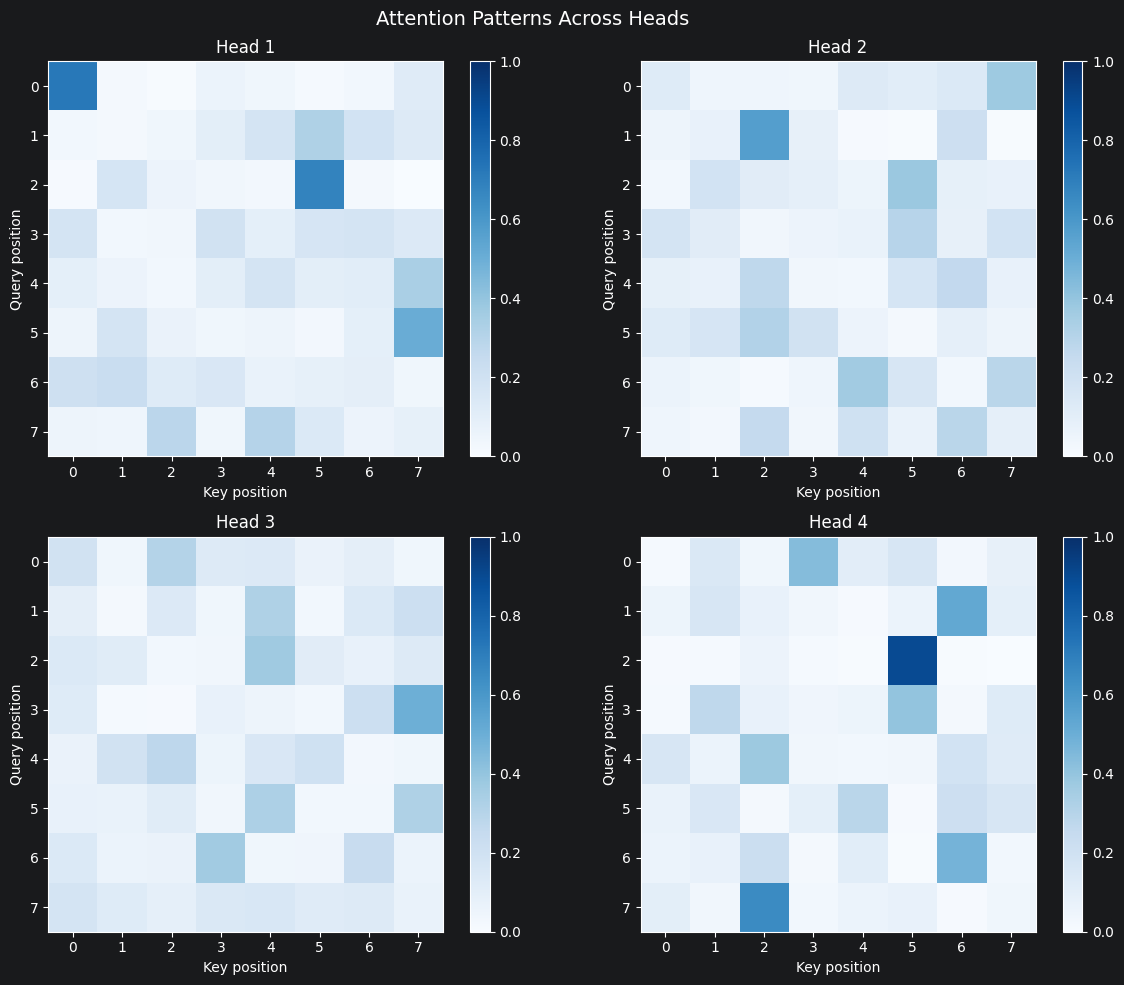

In [4]:
# Визуализируем паттерны внимания разных голов
# Каждая голова может фокусироваться на разных аспектах
torch.manual_seed(42)
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Случайные данные: разные головы дадут разные паттерны
Q = torch.randn(1, 8, d_model) * 2
K = torch.randn(1, 8, d_model) * 2
V = torch.randn(1, 8, d_model) * 2

with torch.no_grad():
    output, attn_weights = mha(Q, K, V)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(attn_weights[0, i].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Attention Patterns Across Heads', fontsize=14)
plt.tight_layout()
plt.show()


## 5.3 Исследование: влияние числа голов

Проверим, как количество голов влияет на количество параметров и скорость.

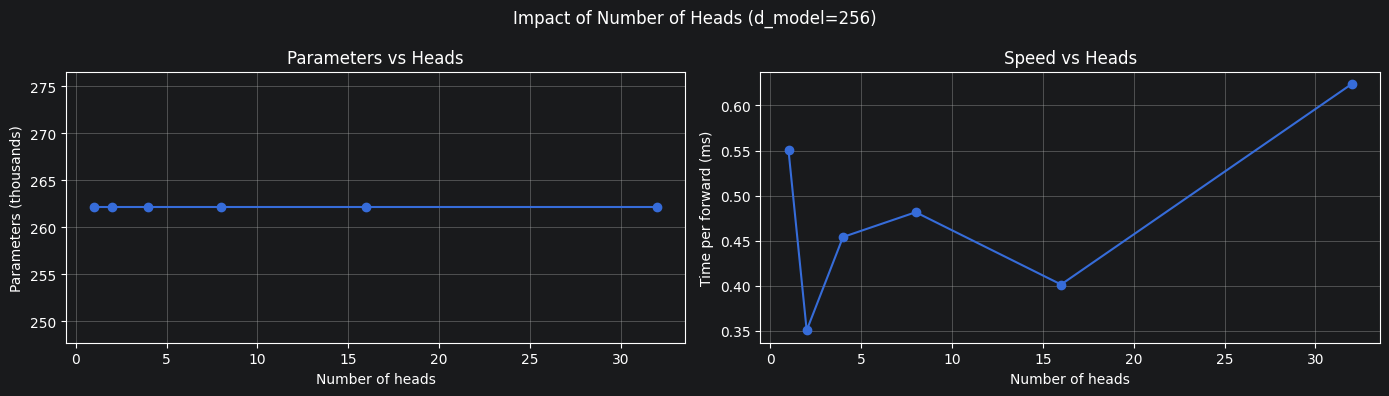

In [6]:
# Исследуем влияние числа голов на параметры и скорость
import time

d_model = 256
head_options = [1, 2, 4, 8, 16, 32]
batch, seq_len = 8, 64

results = []
for n_heads in head_options:
    mha = MultiHeadAttention(d_model, n_heads).to(device)
    params = sum(p.numel() for p in mha.parameters())
    
    Q = torch.randn(batch, seq_len, d_model, device=device)
    K = torch.randn(batch, seq_len, d_model, device=device)
    V = torch.randn(batch, seq_len, d_model, device=device)
    
    # Warmup + синхронизация для точного замера
    for _ in range(5):
        mha(Q, K, V)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(50):
        mha(Q, K, V)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / 50
    
    results.append((n_heads, params, elapsed))

n_heads_arr, params_arr, times_arr = zip(*results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(n_heads_arr, [p/1000 for p in params_arr], 'o-')
axes[0].set_xlabel('Number of heads')
axes[0].set_ylabel('Parameters (thousands)')
axes[0].set_title('Parameters vs Heads')
axes[0].grid(True)

axes[1].plot(n_heads_arr, [t*1000 for t in times_arr], 'o-')
axes[1].set_xlabel('Number of heads')
axes[1].set_ylabel('Time per forward (ms)')
axes[1].set_title('Speed vs Heads')
axes[1].grid(True)

plt.suptitle(f'Impact of Number of Heads (d_model={d_model})')
plt.tight_layout()
plt.show()


## 5.4 Self-Attention: Q=K=V

В энкодере трансформера используется Self-Attention: Q, K, V берутся из одного источника.

In [7]:
# Self-Attention: Q=K=V — все три берутся из одного источника
# Используется в энкодере трансформера
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Один и тот же вход подаётся как Q, K и V
x = torch.randn(1, 6, d_model)
output, attn_weights = mha(x, x, x)

print(f"Self-attention input:  {x.shape}")
print(f"Self-attention output: {output.shape}")
print(f"Attention:             {attn_weights.shape}")

# Диагональ внимания обычно доминирует: токен «смотрит» сам на себя
diag_mean = attn_weights[:, :, range(6), range(6)].mean().item()
print(f"Mean diagonal weight: {diag_mean:.3f} (out of 1.0 per row)")


Self-attention input:  torch.Size([1, 6, 32])
Self-attention output: torch.Size([1, 6, 32])
Attention:             torch.Size([1, 4, 6, 6])
Mean diagonal weight: 0.178 (out of 1.0 per row)


## 5.5 Cross-Attention: Q из одного источника, K, V из другого

В декодере трансформера используется Cross-Attention: Q от декодера, K, V от энкодера.

Decoder (Q) shape:   torch.Size([1, 4, 32])
Encoder (K, V) shape:torch.Size([1, 8, 32])
Cross-attention output:torch.Size([1, 4, 32])
Attention:             torch.Size([1, 4, 4, 8])


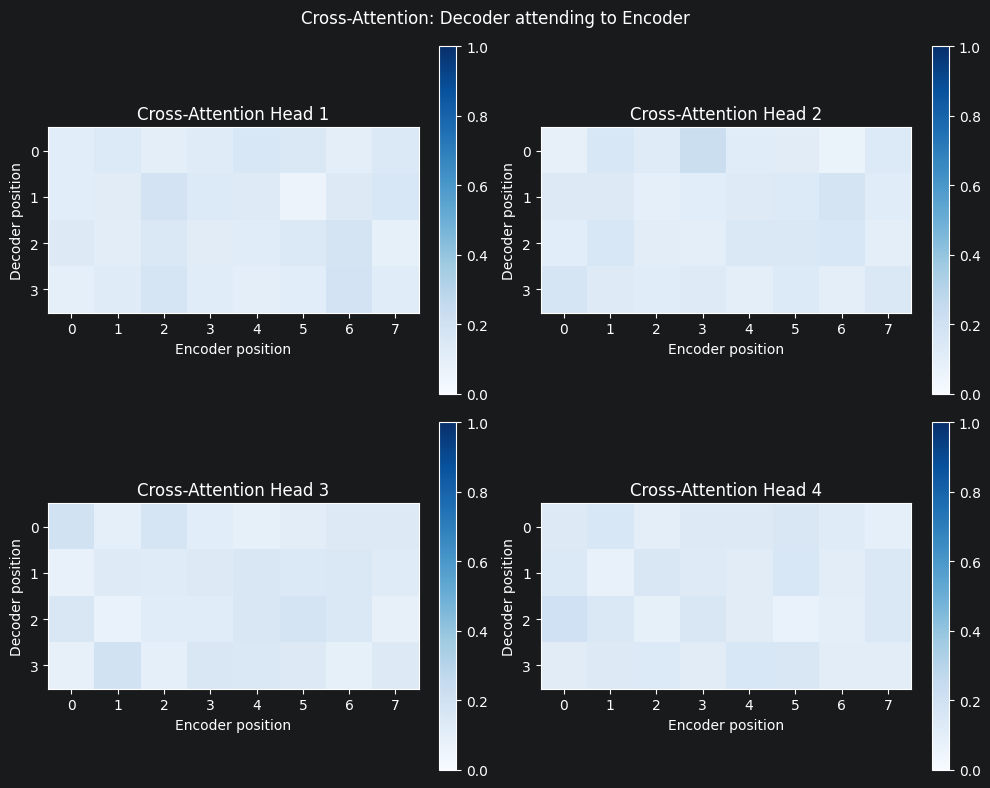

In [8]:
# Cross-Attention: Q из одного источника, K, V из другого
# Используется в декодере: Q от декодера, K, V от энкодера
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Q — выход декодера (4 токена), K, V — выход энкодера (8 токенов)
decoder_output = torch.randn(1, 4, d_model)
encoder_output = torch.randn(1, 8, d_model)

output, attn_weights = mha(decoder_output, encoder_output, encoder_output)

print(f"Decoder (Q) shape:   {decoder_output.shape}")
print(f"Encoder (K, V) shape:{encoder_output.shape}")
print(f"Cross-attention output:{output.shape}")
print(f"Attention:             {attn_weights.shape}")

# Визуализация cross-attention: декодер «смотрит» на выход энкодера
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(attn_weights[0, i].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Cross-Attention Head {i+1}')
    ax.set_xlabel('Encoder position')
    ax.set_ylabel('Decoder position')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Cross-Attention: Decoder attending to Encoder')
plt.tight_layout()
plt.show()


In [9]:
# Подводим итог: Multi-Head Attention освоен
print("=== Multi-Head Attention complete ===")
print("Topics covered:")
print("  - MultiHeadAttention class from scratch")
print("  - Split/combine heads mechanism")
print("  - Visualization of different head patterns")
print("  - Impact of number of heads on params and speed")
print("  - Self-Attention (Q=K=V) vs Cross-Attention")
print("  - Padding mask for multi-head attention")


=== Multi-Head Attention complete ===
Topics covered:
  - MultiHeadAttention class from scratch
  - Split/combine heads mechanism
  - Visualization of different head patterns
  - Impact of number of heads on params and speed
  - Self-Attention (Q=K=V) vs Cross-Attention
  - Padding mask for multi-head attention
